# Lecture 6 - Recap on Experimental Design, the Curse of Dimensionality

---

# Why Performance in Training with a Regularizer is Lower than Without One 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
from sklearn.preprocessing import StandardScaler

def NoisySinusoidalData(N, a, b, sigma):
    '''Generates N data points in the range [a,b) sampled from a sin(2*pi*x) 
    with additive zero-mean Gaussian random noise with standard deviation sigma'''

    # # Fixing random seed for reproducibility
    # np.random.seed(42)
    
    # N input samples, evenly spaced numbers between [a,b) incrementing by 1/N
    x = np.linspace(a,b,N)
    
    # draw N sampled from a univariate Gaussian distribution with mean 0, sigma standard deviation and N data points
    noise = np.random.normal(0,sigma,N,)
    
    # desired values, noisy sinusoidal
    t = np.sin(2*np.pi*x) + noise
    
    return x, t

def PolynomialRegression(x,t,M):
    '''Fit a polynomial of order M to the data input data x and desire values t.
    MSE objective function.'''
    
    # Compute feature matrix X with polynomial features
    X = np.array([x**i for i in range(M+1)]).T # this creates an N-by-(M+1) matrix
    
    # Compute the solution for the parameters w, using the MSE ojective function
    w = np.linalg.inv(X.T@X)@X.T@t 
    
    # Compute model prediction
    y = X@w
    
    return w, y

def PolynomialRegression_test(x_test, w):
    '''Use a trained linear regression model with polynomial features for inference.'''
    # Compute test feature matrix
    X_test = np.array([x_test**i for i in range(len(w))]).T # this is a N_test-by-(M+1) matrix
    
    # Prediction for test samples using the trained model
    y_test = X_test@w
    
    return y_test

def PolynomialRegression_reg(x,t,M,lam):
    '''Fit a polynomial of order M to the data input data x and desire values t. 
    MSE objective function with the Ridge regularizer.'''
    
    # Compute feature matrix X with polynomial features
    X = np.array([x**i for i in range(M+1)]).T # this creates an N-by-(M+1) matrix
    
    # Compute the solution for the parameters w, using the MSE ojective function
    w = np.linalg.inv(X.T@X + lam*np.eye(M+1))@X.T@t 
    
    # Compute model prediction
    y = X@w
    
    return w, y

In [16]:
experiment = np.zeros((1000,4))

# Parameters for Generating Data
N_train = 70 # number of data samples for training
N_test = 20 # number of data samples for test
a, b = [0,1] # data samples interval
sigma_train = 0.4 # standard deviation of the zero-mean Gaussian noise -- training data
sigma_test = 0.6 # standard deviation of the zero-mean Gaussian noise -- test data

# Parameters for Polynomial Regressoion w/ and w/out Regularization
M=15
lam=0.02

for i in range(1000):
    x_train, t_train = NoisySinusoidalData(N_train, a, b, sigma_train) # Training Data - Noisy sinusoidal
    x_true, t_true = NoisySinusoidalData(N_train, a, b, 0) # True Sinusoidal - in practice, we don't have the true fct
    
    scaler = StandardScaler() # f_scaled = (f-mean(f))/std(f)
    x_train_scaled = scaler.fit_transform(x_train[:,np.newaxis]).ravel()
    x_true_scaled = scaler.transform(x_true[:,np.newaxis]).ravel()

    ## Not scaled data
    w, y = PolynomialRegression(x_train,t_train,M) 
    w_reg, y_reg  = PolynomialRegression_reg(x_train,t_train,M,lam)

    ## Scaled data
    w_scaled, y_scaled = PolynomialRegression(x_train_scaled,t_train,M) 
    w_reg_scaled, y_reg_scaled = PolynomialRegression_reg(x_train_scaled,t_train,M,lam)
    
    ## Predictions in training/test sets with and without regularization
    y = PolynomialRegression_test(x_train, w)
    y_scaled = PolynomialRegression_test(x_train_scaled, w_scaled)
    y_reg = PolynomialRegression_test(x_train, w_reg)
    y_reg_scaled = PolynomialRegression_test(x_train_scaled, w_reg_scaled)
    
    ## Error Measures
    # Residual error for Training data for polynomial regression without and with regularizer
    mse_train = np.mean((t_train - y)**2)
    mse_train_scaled = np.mean((t_train - y_scaled)**2)
    mse_train_reg = np.mean((t_train - y_reg)**2)
    mse_train_reg_scaled = np.mean((t_train - y_reg_scaled)**2)

    experiment[i,:] = [mse_train, mse_train_scaled, mse_train_reg, mse_train_reg_scaled]

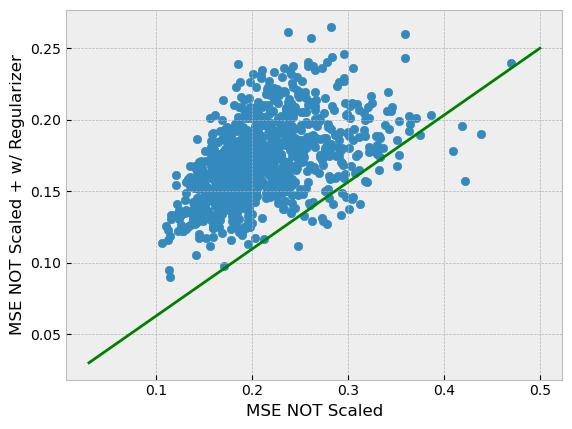

In [17]:
plt.scatter(experiment[:,0], experiment[:,2])
plt.plot(np.linspace(0.03,0.5,100),np.linspace(0.03,0.25,100), 'g')
plt.xlabel('MSE NOT Scaled')
plt.ylabel('MSE NOT Scaled + w/ Regularizer');

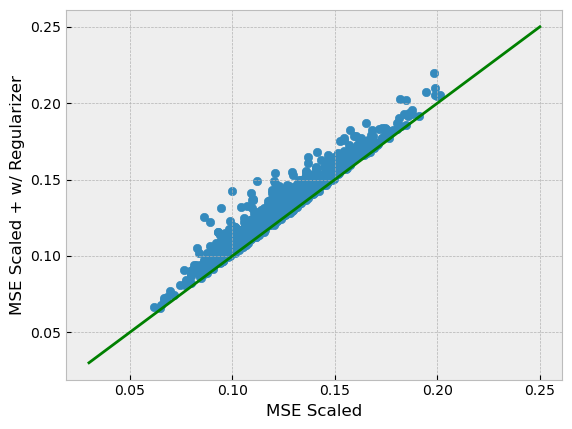

In [18]:
plt.scatter(experiment[:,1], experiment[:,3])
plt.plot(np.linspace(0.03,0.25,100),np.linspace(0.03,0.25,100), 'g')
plt.xlabel('MSE Scaled')
plt.ylabel('MSE Scaled + w/ Regularizer');

<div class="alert alert-info">
    <b>Take-Home Message</b> 

Always **scale your data** prior to carry model design choices and hyperparameter tuning.
</div>

---

# Recap - Experimental Design

## Strategies to Mitigate Overfitting

1. Add more data! - when possible

2. Occam's Razor - select a model with lower complexity

3. Regularization - constrains/regularizes the coefficients of the model

4. Cross-validation - technique for utilizing the training data to fine-tune hyperparameter values

## Cross-Validation Schemes

We first must select a **performance measure**, e.g. mean square error (MSE), or the coefficient of determination $r^2$. There are different strategies for implementing cross-validation:

1. $k\times 2$ cross-validation
2. k-fold cross-validation
3. Leave-One-Out cross-validation
4. Stratified cross-validation
5. Bootstrapping

For classification tasks, we must ensure that classes are represented in the right proportions when subsets of data are held out, as to not to disturb the class prior probabilities; this is called **stratiﬁcation**. If a class has 20 percent examples in the whole dataset, in all samples drawn from the dataset, it should also have approximately 20 percent examples in all subsets.

<div class="alert alert-info">
    <b>The No Free Lunch Theorem</b> 

The No Free Lunch Theorem states that there is no single learning algorithm that in any domain always induces the most accurate learner. The usual approach is to try many and choose the one that performs the best on a separate validation set.
    
For any learning algorithm, there is a dataset where it is very accurate and another dataset where it is very poor. When we say that a learning algorithm is good, we only quantify how well its inductive bias matches the properties of the data.
</div>

---

# The Curse of Dimensionality

The Curse of Dimensionality illustrates various phenomena that arise when we work with high-dimensional data spaces that would not otherwise occur in lower-dimensional settings (such as the 3-dimensional space).

> ## Our intuitions do not hold in high-dimensional spaces 🤔

Let's illustrate this with two examples.

## Example 1: Volume of a Crust

Consider two embedded spheres, $S_1$ and $S_2$, where sphere $S_1$ has radius $r$, sphere $S_2$ has radius $r-\epsilon$, with $0<\epsilon<r$.

Let's calculate the ratio between the volume of the crust and the volume of the outer sphere $S_1$:

\begin{align*}
\text{ratio} = \frac{V_{crust}}{V_{S_1}} = \frac{V_{S_1} - V_{S_2}}{V_{S_1}}
\end{align*}

* The $D$-dimensional [volume of a sphere of radius $r$ in $D$-dimensional space](https://en.wikipedia.org/wiki/Volume_of_an_n-ball) is: $V = \frac{r^D \pi^{\frac{D}{2}}}{\Gamma\left(\frac{D}{2}+1\right)}$, then

\begin{align*}
\text{ratio} &= \frac{V_{S_1} - V_{S_2}}{V_{S_1}} \\
&= 1-\frac{V_{S_2}}{V_{S_1}} \\
&= 1-\frac{\frac{(r-\epsilon)^D \pi^{\frac{D}{2}}}{\Gamma\left(\frac{D}{2}+1\right)}}{\frac{r^D \pi^{\frac{D}{2}}}{\Gamma\left(\frac{D}{2}+1\right)}} \\
&= 1 - \frac{(r-\epsilon)^D}{r^D}\\
&= 1 - \frac{r^D\left(1-\frac{\epsilon}{r}\right)^D}{r^D}\\
&= 1 - \left(1-\frac{\epsilon}{r}\right)^D
\end{align*}

* For a fixed value for $\epsilon$, a fixed radius $r$ and $\epsilon<r$, what happens as $D$ increases?

<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
/var/folders/4p/y0h9xc8s5jq1s8b859ly3f5r0000gn/T/ipykernel_27111/1163057147.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('ratio$=1 - (1 - \epsilon/r)^D$',size=15)


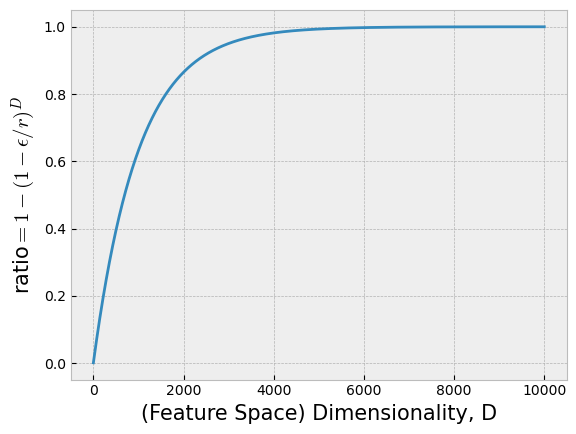

In [3]:
# Crust volume between spheres with epsilon different radii and increasing dimensionality

r = 1 # radius of outer sphere
eps = 0.001 # epsilon value
D = range(1,10000) # dimensionality
RatioVol = [1-(1-eps/r)**d for d in D] # ratio of the volume as a function of dimensionality D
plt.plot(D, RatioVol) # plotting results
plt.ylabel('ratio$=1 - (1 - \epsilon/r)^D$',size=15)
plt.xlabel('(Feature Space) Dimensionality, D',size=15);

> ### 🤯 Let's see another example!

## Example 2: Unit Porcupine

Consider the unit porcupine which is represented as a unit hypersphere inscribed within a unit hypercube.

Recall that the $D$-dimensional volume of a $D$-dimensional cube with radius $r$ is $(2r)^D$.

* What happens to the ratio between the volume of the sphere and the volume of the cube as dimensionality $D$ increases?

\begin{align*}
\frac{V(\text{sphere})}{V(\text{cube})} &= \frac{\frac{r^D \pi^{\frac{D}{2}}}{\Gamma\left(\frac{D}{2}+1\right)}}{(2r)^D}\\
&= \frac{r^D \pi^{\frac{D}{2}}}{(2r)^D\Gamma\left(\frac{D}{2}+1\right)}\\
&= \frac{\pi^{\frac{D}{2}}}{2^D\Gamma\left(\frac{D}{2}+1\right)}
\end{align*}

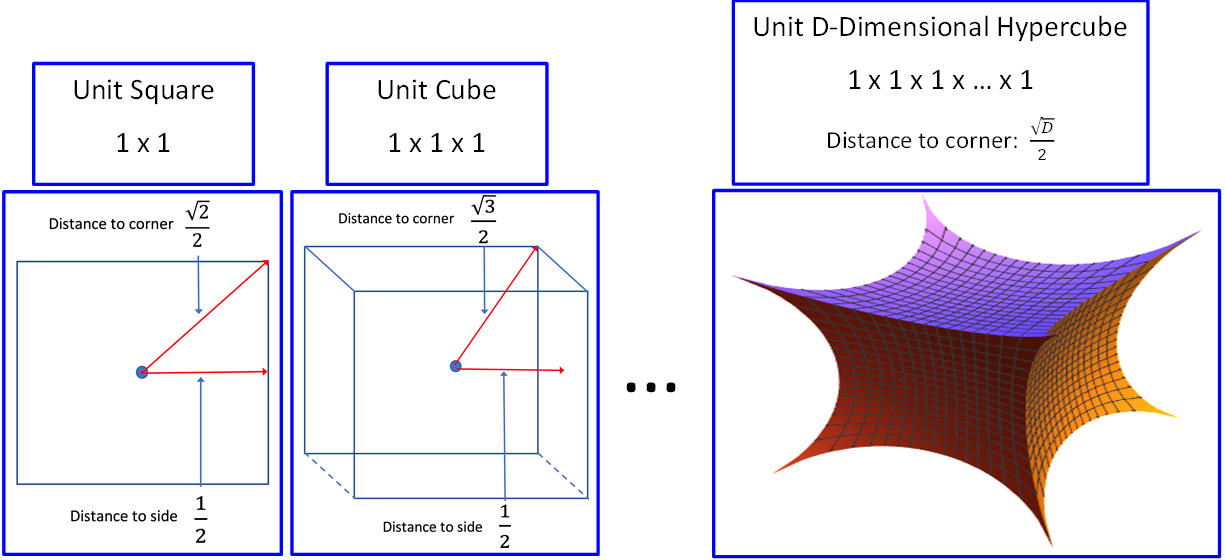

In [6]:
from IPython.display import Image

Image('figures/hypercube.png',width=1000)

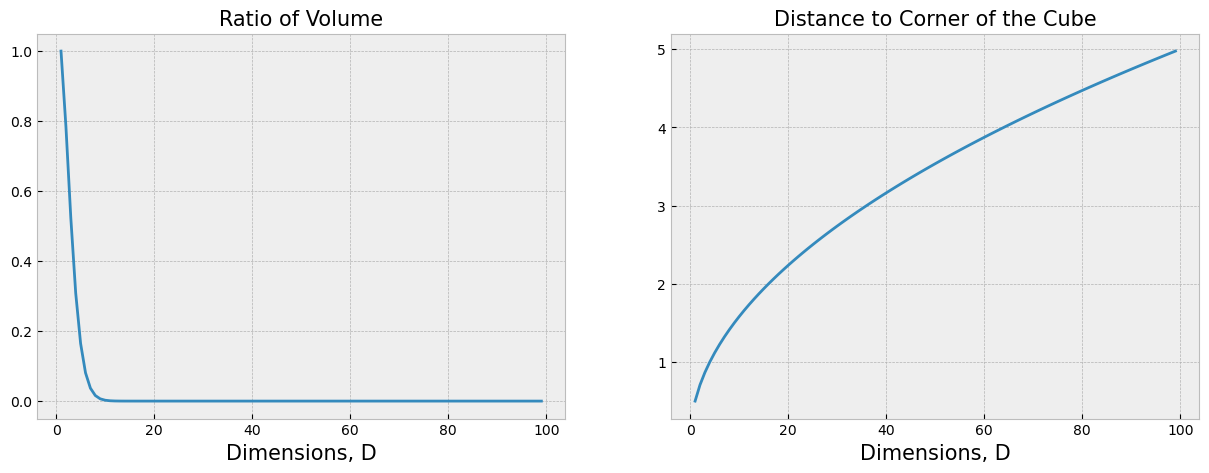

In [7]:
# The Unit Porcupine (the unit hyper-sphere inscribed within the unit hyper-cube)

import math

D = range(1,100) # dimensionality, D
V = [np.pi**(i/2)/(2**i*math.gamma(i/2 + 1)) for i in D] # ratio as a function of dimensionality D
dist_to_Corner = [math.sqrt(d)/2 for d in D] # distance 

# plotting
plt.figure(figsize=(15,5))
plt.subplot(1,2,1); plt.plot(D, V) 
plt.title('Ratio of Volume',size=15)
plt.xlabel('Dimensions, D',size=15)

plt.subplot(1,2,2)
plt.plot(D, dist_to_Corner) 
plt.title('Distance to Corner of the Cube',size=15)
plt.xlabel('Dimensions, D',size=15);

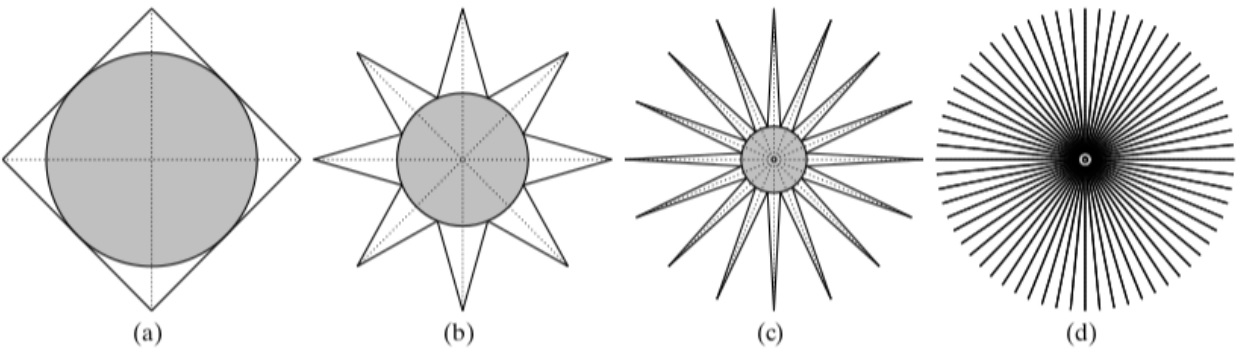

In [8]:
Image('figures/Unit Porcupine.jpg',width=800)

## Discussions

In the unit porcupine example, for higher-dimensionality $D$, all of the volume will reside in the "corners". So, distances between neighboring points is extremely large. The notion of **similarity** as measure by distances becomes a challenge.

As the dimensionality of the feature space increases, we need exponentially more data in order to explain a highly increasing volume.

We need to be careful choosing a model as that choice "injects" what we want the data to look like or follow a specific behavior. For example, in higher-dimensions, the tails of a Gaussian density function will become highly dense.

Always employ the **Occam's Razor** principle: the simplest model that works for our data is usually the most appropriate and sufficient. Model simplicity can mean different things, but we can consider a model to be complex if it has too many hyperparameter values to configure. 

When we are in a high-dimensional input space (such as images), much of that space is empty. The input data can be represented in only a few *degrees of freedom* of variability. We say that the data in *embedded* in a **manifold** of equal dimensionality as the degrees of freedom (which is drastically smaller than the input space dimensionality). We will study a few dimensionality reduction and manifold learning techniques later on in this course.

And again, intuitions or assumptions do not always hold in higher dimensions.

---
---
---